In [ ]:
import pandas as pd

# Load the file — first column is gene IDs, rest are sample counts
df = pd.read_csv("GSE234297_gene_raw_counts.txt.gz", sep="\t", compression="gzip")

# Assume the first column is the gene ID column — set it as index
gene_col = df.columns[0]
df = df.set_index(gene_col)

# Check whether any values are non-integer
has_decimals = (df % 1 != 0).any().any()
print(f"Contains non-integer values: {has_decimals}")

# Show a few decimal examples if present, just to confirm what you're dealing with
if has_decimals:
    decimal_mask = df % 1 != 0
    print("Example non-integer entries:")
    print(df.where(decimal_mask).stack().head(10))

# Round to nearest integer (DESeq2 requires whole-number counts)
df_rounded = df.round(0).astype(int)

# Quick sanity check: library size (total counts) per sample
library_sizes = df_rounded.sum(axis=0)
print("\nLibrary size summary:")
print(library_sizes.describe())

# Flag any sample whose library size is far below the rest (potential exclusion candidate)
median_size = library_sizes.median()
low_samples = library_sizes[library_sizes < 0.3 * median_size]
if len(low_samples) > 0:
    print(f"\nWarning — samples with unusually low library size (<30% of median):")
    print(low_samples)

# Save the cleaned, integer counts matrix
df_rounded.to_csv("GSE234297_gene_raw_counts_rounded.txt", sep="\t")
print("\nSaved cleaned file: GSE234297_gene_raw_counts_rounded.txt")

FileNotFoundError: [Errno 2] No such file or directory: 'GSE234297_gene_raw_counts.txt.gz'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
from google.colab import files
files.download("GSE234297_gene_raw_counts_rounded.txt")

In [ ]:
import pandas as pd

# Load the counts file to confirm column names match exactly
df = pd.read_csv("GSE234297_gene_raw_counts_rounded.txt", sep="\t", index_col=0)

sample_names = df.columns.tolist()
print(f"Total samples: {len(sample_names)}")

# Build phenotype table based on the confirmed naming pattern
phenotype = pd.DataFrame({
    "sample": sample_names,
    "condition": ["ALS" if s.startswith("Case") else "control" for s in sample_names]
})

# Sanity check: counts should be 96 ALS, 48 control
print(phenotype["condition"].value_counts())

# Save as tab-separated file, ready to upload to Galaxy
phenotype.to_csv("GSE234297_phenotype.txt", sep="\t", index=False)
print("Saved: GSE234297_phenotype.txt")

Total samples: 144
condition
ALS        96
control    48
Name: count, dtype: int64
Saved: GSE234297_phenotype.txt


In [ ]:
import pandas as pd
import numpy as np

# Load counts
counts = pd.read_csv("GSE234297_gene_raw_counts_rounded.txt", sep="\t", index_col=0)
print("Step 1 - counts loaded. Shape:", counts.shape, "| NaNs:", counts.isna().sum().sum())

# Transpose
counts_t = counts.T
print("Step 2 - transposed. Shape:", counts_t.shape, "| NaNs:", counts_t.isna().sum().sum())

# Load phenotype
pheno = pd.read_csv("GSE234297_phenotype.txt", sep="\t")
pheno = pheno.set_index("sample")
print("Step 3 - phenotype loaded. Shape:", pheno.shape)
print("Phenotype samples missing from counts:", set(pheno.index) - set(counts_t.index))
print("Counts samples missing from phenotype:", set(counts_t.index) - set(pheno.index))

# Align — use reindex with explicit check instead of .loc, so mismatches are visible not silent
pheno = pheno.reindex(counts_t.index)
print("Step 4 - after alignment. NaNs in phenotype condition column:", pheno["condition"].isna().sum())

pheno["condition"] = pd.Categorical(pheno["condition"], categories=["control", "ALS"])

# Final check before building the dataset
print("Step 5 - final counts NaNs:", counts_t.isna().sum().sum())
print("Step 5 - counts_t dtypes:", counts_t.dtypes.unique())

Step 1 - counts loaded. Shape: (46025, 144) | NaNs: 0
Step 2 - transposed. Shape: (144, 46025) | NaNs: 0
Step 3 - phenotype loaded. Shape: (144, 1)
Phenotype samples missing from counts: set()
Counts samples missing from phenotype: set()
Step 4 - after alignment. NaNs in phenotype condition column: 0
Step 5 - final counts NaNs: 0
Step 5 - counts_t dtypes: [dtype('int64')]


In [ ]:
import pandas as pd

# Install pydeseq2 if not already installed
try:
    import pydeseq2
    from pydeseq2.dds import DeseqDataSet
    from pydeseq2.ds import DeseqStats
except ImportError:
    !pip install pydeseq2
    import pydeseq2
    from pydeseq2.dds import DeseqDataSet
    from pydeseq2.ds import DeseqStats

counts = pd.read_csv("GSE234297_gene_raw_counts_rounded.txt", sep="\t", index_col=0)
counts_t = counts.T

pheno = pd.read_csv("GSE234297_phenotype.txt", sep="\t").set_index("sample")
pheno = pheno.reindex(counts_t.index)
pheno["condition"] = pd.Categorical(pheno["condition"], categories=["control", "ALS"])

# Remove genes with zero counts across ALL samples — standard pre-filtering step,
# but essential here since PyDESeq2 can't handle the log(0) this produces internally
nonzero_genes = counts_t.sum(axis=0) > 0
print("Genes with all-zero counts (removed):", (~nonzero_genes).sum())
counts_t = counts_t.loc[:, nonzero_genes]
print("Remaining genes:", counts_t.shape[1])

dds = DeseqDataSet(
    counts=counts_t,
    metadata=pheno,
    design_factors="condition",
    ref_level=["condition", "control"],
)
dds.deseq2()

stat_res = DeseqStats(dds, contrast=["condition", "ALS", "control"])
stat_res.summary()
results_df = stat_res.results_df.sort_values("padj")
results_df.to_csv("GSE234297_DESeq2_results.txt", sep="\t")

Genes with all-zero counts (removed): 16158
Remaining genes: 29867


/usr/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/tmp/ipykernel_1521/2077806808.py:28: DeprecationWarning: ref_level is deprecated and no longer has any effect. It will beremoved in a future release.
  dds = DeseqDataSet(
/tmp/ipykernel_1521/2077806808.py:28: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.79 seconds.

Fitting dispersions...
... done in 51.10 seconds.

Fitting dispersion trend curve...
... done in 1.06 seconds.

Fitting MAP dispersions...
... done in 58.85 seconds.

Fitting LFCs...
... done in 39.55 seconds.

Calculating cook's distance...
... done in 0.38 seconds.

Replacing 164 outlier genes.

Fitting dispersions...
... done in 0.31 seconds.

Fitting MAP dispersions...
... done in 0.32 seconds.

Fitting LFCs...
... done in 0.26 seconds.

Running Wald tests...
... done in 9.34 seconds.



Log2 fold change & Wald test p-value: condition ALS vs control
               baseMean  log2FoldChange     lfcSE      stat    pvalue  padj
EntrezGeneID                                                               
1             20.806203       -0.171332  0.151083 -1.134026  0.256784   NaN
2              1.452421        0.007479  0.298289  0.025072  0.979998   NaN
3              0.022674       -0.042070  3.117167 -0.013496  0.989232   NaN
9              8.617032        0.211601  0.165346  1.279747  0.200634   NaN
10             0.007128        0.294478  3.125994  0.094203  0.924948   NaN
...                 ...             ...       ...       ...       ...   ...
116412618      2.147173        0.411937  0.379792  1.084638  0.278082   NaN
116435278      0.015177        0.321852  3.125590  0.102973  0.917984   NaN
116804915      0.006982        0.294478  3.125994  0.094203  0.924948   NaN
116804918      1.505771        0.311764  0.391273  0.796794  0.425571   NaN
117779438      0.550236  

In [ ]:
import pandas as pd

# Install pydeseq2 if not already installed
try:
    import pydeseq2
    from pydeseq2.dds import DeseqDataSet
    from pydeseq2.ds import DeseqStats
except ImportError:
    !pip install pydeseq2
    import pydeseq2
    from pydeseq2.dds import DeseqDataSet
    from pydeseq2.ds import DeseqStats

counts = pd.read_csv("GSE234297_gene_raw_counts_rounded.txt", sep="\t", index_col=0)
counts_t = counts.T

pheno = pd.read_csv("GSE234297_phenotype.txt", sep="\t").set_index("sample")
pheno = pheno.reindex(counts_t.index)
pheno["condition"] = pd.Categorical(pheno["condition"], categories=["control", "ALS"])

# Remove genes with zero counts across ALL samples — standard pre-filtering step,
# but essential here since PyDESeq2 can't handle the log(0) this produces internally
nonzero_genes = counts_t.sum(axis=0) > 0
print("Genes with all-zero counts (removed):", (~nonzero_genes).sum())
counts_t = counts_t.loc[:, nonzero_genes]
print("Remaining genes:", counts_t.shape[1])

dds = DeseqDataSet(
    counts=counts_t,
    metadata=pheno,
    design_factors="condition",
    ref_level=["condition", "control"],
)
dds.deseq2()

stat_res = DeseqStats(dds, contrast=["condition", "ALS", "control"])
stat_res.summary()
results_df = stat_res.results_df.sort_values("padj")
results_df.to_csv("GSE234297_DESeq2_results.txt", sep="\t")

Genes with all-zero counts (removed): 16158
Remaining genes: 29867
Using None as control genes, passed at DeseqDataSet initialization


/usr/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/tmp/ipykernel_1521/2077806808.py:28: DeprecationWarning: ref_level is deprecated and no longer has any effect. It will beremoved in a future release.
  dds = DeseqDataSet(
/tmp/ipykernel_1521/2077806808.py:28: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.22 seconds.

Fitting dispersions...
... done in 49.39 seconds.

Fitting dispersion trend curve...
... done in 1.15 seconds.

Fitting MAP dispersions...
... done in 55.39 seconds.

Fitting LFCs...
... done in 39.69 seconds.

Calculating cook's distance...
... done in 0.33 seconds.

Replacing 164 outlier genes.

Fitting dispersions...
... done in 0.31 seconds.

Fitting MAP dispersions...
... done in 0.32 seconds.

Fitting LFCs...

Log2 fold change & Wald test p-value: condition ALS vs control
               baseMean  log2FoldChange     lfcSE      stat    pvalue  padj
EntrezGeneID                                                               
1             20.806203       -0.171332  0.151083 -1.134026  0.256784   NaN
2              1.452421        0.007479  0.298289  0.025072  0.979998   NaN
3              0.022674       -0.042070  3.117167 -0.013496  0.989232   NaN
9              8.617032        0.211601  0.165346  1.279747  0.200634   NaN
10             0.007128        0.294478  3.125994  0.094203  0.924948   NaN
...                 ...             ...       ...       ...       ...   ...
116412618      2.147173        0.411937  0.379792  1.084638  0.278082   NaN
116435278      0.015177        0.321852  3.125590  0.102973  0.917984   NaN
116804915      0.006982        0.294478  3.125994  0.094203  0.924948   NaN
116804918      1.505771        0.311764  0.391273  0.796794  0.425571   NaN
117779438      0.550236  

In [ ]:
non_nan_padj = results_df["padj"].notna().sum()
print(f"Genes with valid padj: {non_nan_padj} out of {len(results_df)}")

# Show the actual top hits, sorted properly (NaNs pushed to the end)
top_hits = results_df.sort_values("padj", na_position="last")
print(top_hits.head(20))

Genes with valid padj: 6704 out of 29867
                baseMean  log2FoldChange     lfcSE      stat    pvalue  \
EntrezGeneID                                                             
8761          374.038692       -0.174745  0.042178 -4.143038  0.000034   
6732          206.033928        0.449381  0.107008  4.199511  0.000027   
53829         860.466392        0.388415  0.086520  4.489290  0.000007   
5359          122.935046        0.482677  0.112498  4.290555  0.000018   
100289678     150.232026       -0.241266  0.059169 -4.077607  0.000046   
306           111.300762        0.548529  0.135202  4.057098  0.000050   
200315        962.546101        0.381319  0.092837  4.107416  0.000040   
5610          201.510283        0.578870  0.134881  4.291706  0.000018   
1230          348.651891        0.423590  0.101936  4.155464  0.000032   
9541          194.679911        0.357058  0.085939  4.154804  0.000033   
3772          900.867022        0.420329  0.103233  4.071645  0.000047 

In [ ]:
sig_degs = results_df[
    (results_df["padj"] < 0.05) &
    (results_df["log2FoldChange"].abs() > 1)  # note: many papers use >1, some >2 — see note below
]
print(f"Significant DEGs: {len(sig_degs)}")

sig_degs.to_csv("GSE234297_significant_DEGs.txt", sep="\t")

Significant DEGs: 1


In [ ]:
for fc_cutoff in [0, 0.585, 1, 1.5, 2]:
    n = ((results_df["padj"] < 0.05) & (results_df["log2FoldChange"].abs() > fc_cutoff)).sum()
    print(f"|log2FC| > {fc_cutoff}: {n} genes")

|log2FC| > 0: 290 genes
|log2FC| > 0.585: 7 genes
|log2FC| > 1: 1 genes
|log2FC| > 1.5: 0 genes
|log2FC| > 2: 0 genes


In [ ]:
sig_degs = results_df[results_df["padj"] < 0.05]
print(f"Final significant DEGs: {len(sig_degs)}")

sig_degs.to_csv("GSE234297_significant_DEGs.txt", sep="\t")
sig_degs.index.to_series().to_csv("GSE234297_DEG_gene_list.txt", index=False, header=False)

Final significant DEGs: 290


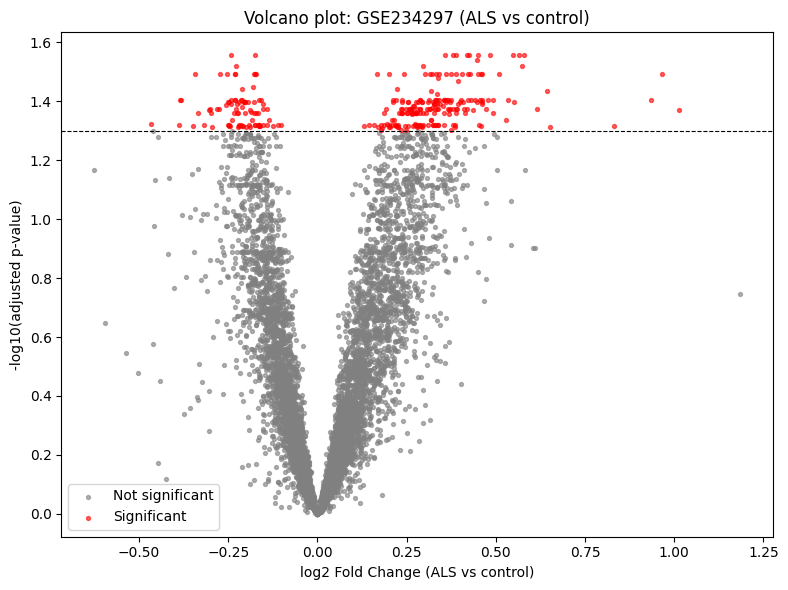

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

df = results_df.copy()
df = df.dropna(subset=["padj"])  # drop genes that didn't get a padj (independent filtering)

df["-log10(padj)"] = -np.log10(df["padj"])

# Classify genes for coloring
def classify(row):
    if row["padj"] < 0.05:
        return "Significant"
    return "Not significant"

df["status"] = df.apply(classify, axis=1)

plt.figure(figsize=(8, 6))
colors = {"Significant": "red", "Not significant": "grey"}
for status, group in df.groupby("status"):
    plt.scatter(group["log2FoldChange"], group["-log10(padj)"],
                s=8, alpha=0.6, label=status, color=colors[status])

plt.axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=0.8)
plt.xlabel("log2 Fold Change (ALS vs control)")
plt.ylabel("-log10(adjusted p-value)")
plt.title("Volcano plot: GSE234297 (ALS vs control)")
plt.legend()
plt.tight_layout()
plt.savefig("GSE234297_volcano_plot.png", dpi=300)
plt.show()

In [ ]:
normalized_counts = dds.layers["normed_counts"]
normalized_counts_df = pd.DataFrame(
    normalized_counts,
    index=dds.obs_names,
    columns=dds.var_names
)
print(normalized_counts_df.shape)

(144, 29867)


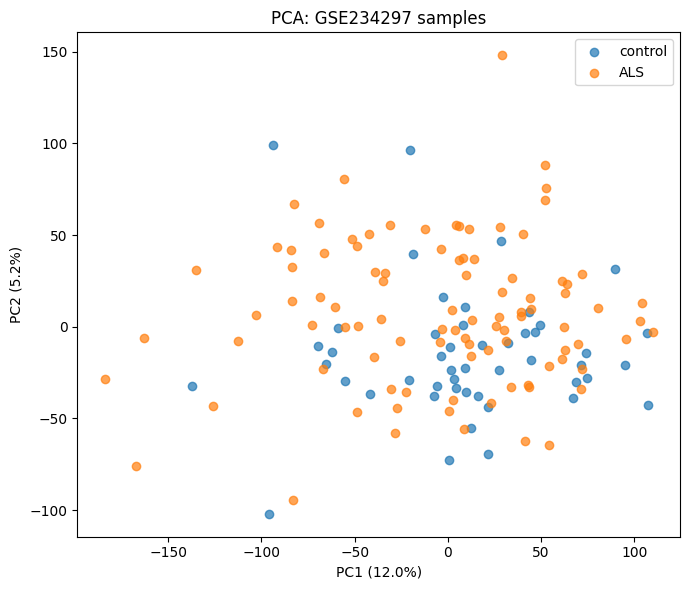

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Use normalized counts, log-transformed for PCA (standard practice)
log_norm = np.log2(normalized_counts_df + 1)

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(StandardScaler().fit_transform(log_norm))

pca_df = pd.DataFrame(pca_coords, columns=["PC1", "PC2"], index=normalized_counts_df.index)
pca_df = pca_df.merge(pheno, left_index=True, right_index=True)

plt.figure(figsize=(7, 6))
for condition, group in pca_df.groupby("condition"):
    plt.scatter(group["PC1"], group["PC2"], label=condition, alpha=0.7)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA: GSE234297 samples")
plt.legend()
plt.tight_layout()
plt.savefig("GSE234297_PCA_plot.png", dpi=300)
plt.show()

In [ ]:
normalized_counts_df.to_csv("GSE234297_normalized_counts.txt", sep="\t")
results_df.to_csv("GSE234297_DESeq2_full_results.txt", sep="\t")

In [ ]:
from google.colab import files

files.download("GSE234297_normalized_counts.txt")
files.download("GSE234297_DESeq2_full_results.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install PyWGCNA -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 748.9/748.9 kB 24.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.7/689.7 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 44.9 MB/s eta 0:00:00


Saving data to be True, checking requirements ...
Figure directory does not exist!
Creating figure directory!
Pre-processing...
	Detecting genes and samples with too many missing values...
	Done pre-processing..



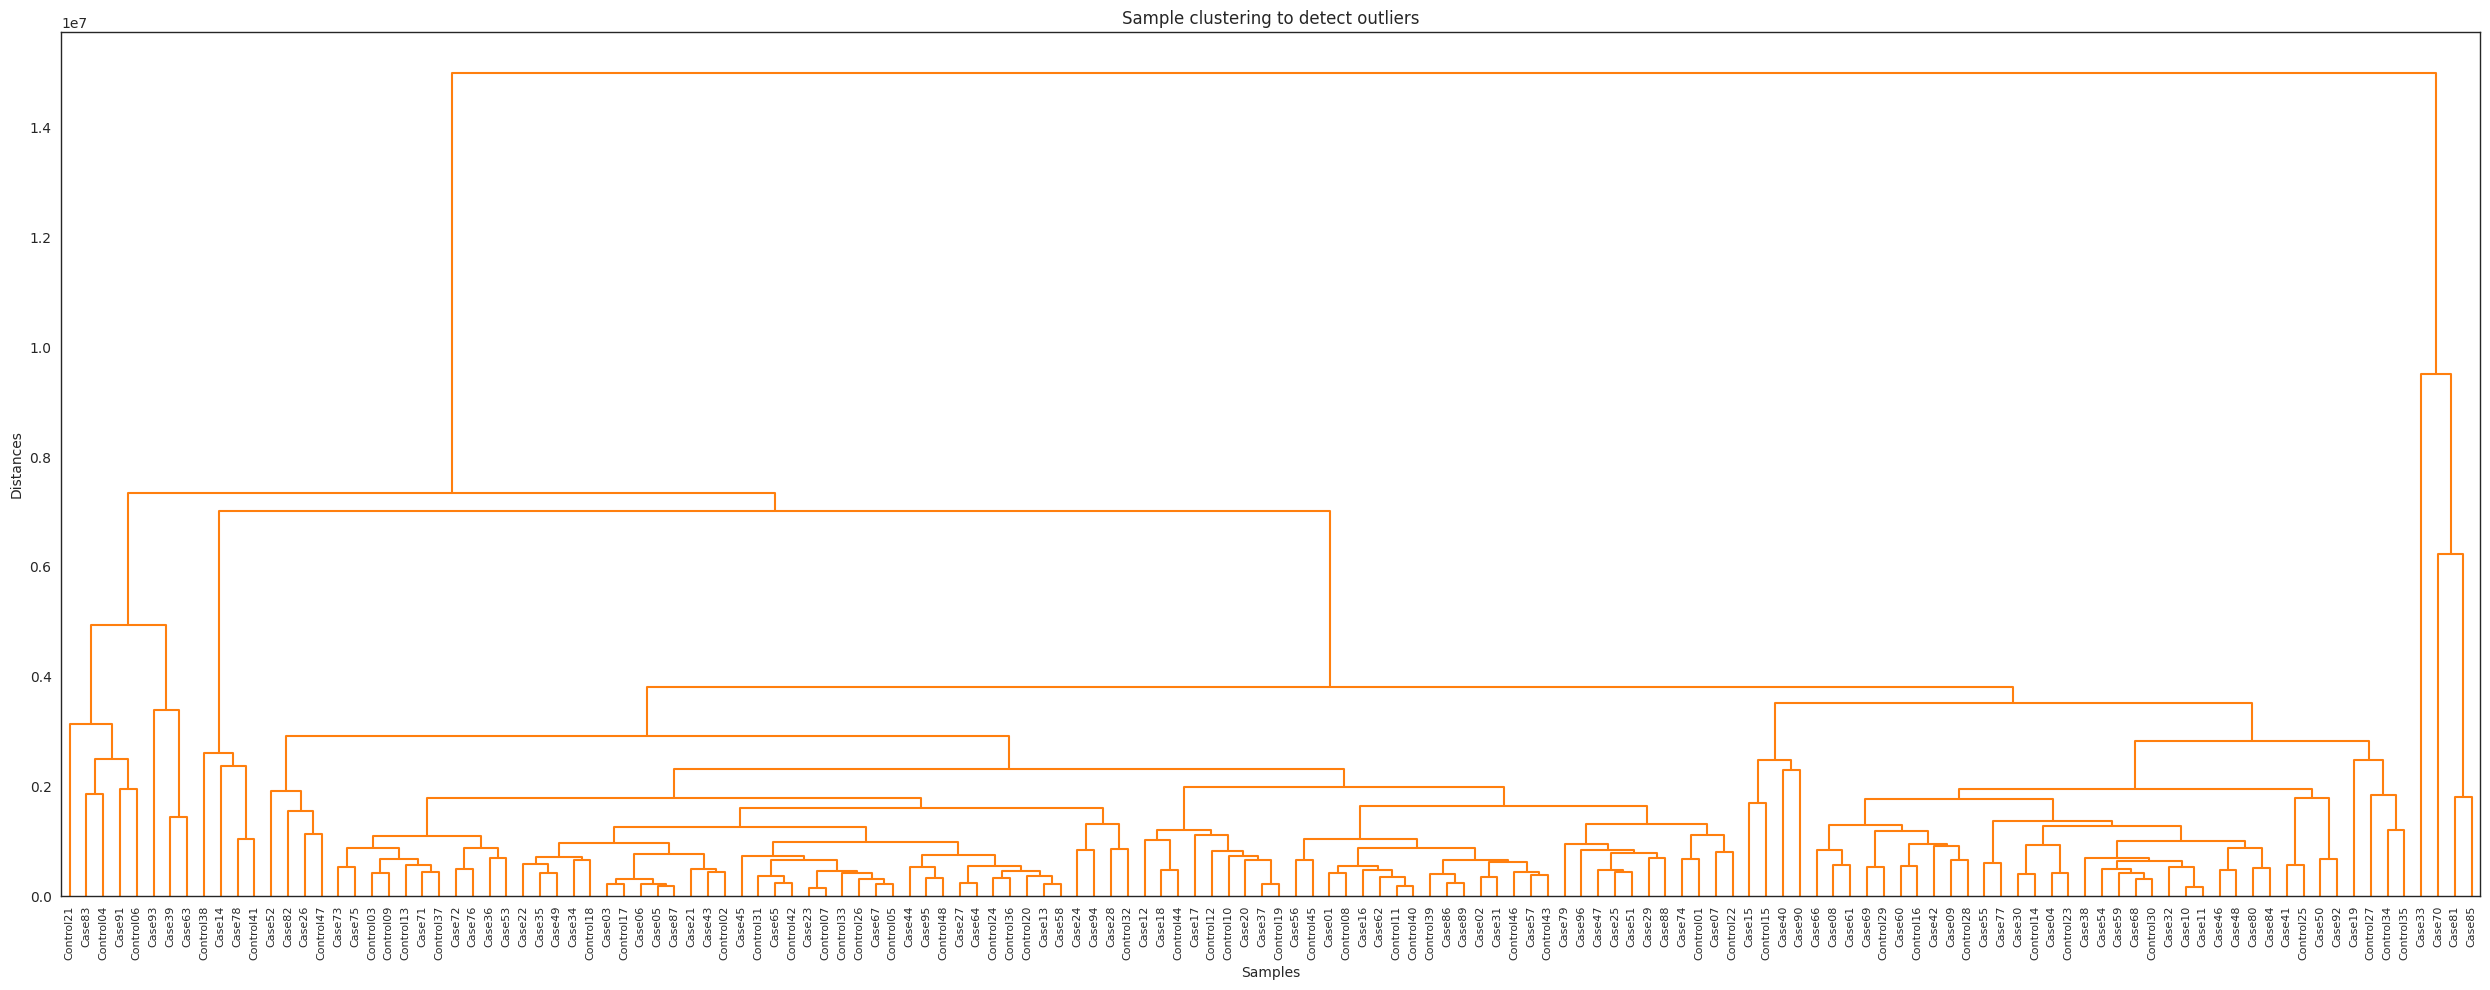

In [ ]:
import PyWGCNA

pyWGCNA_ALS = PyWGCNA.WGCNA(
    name='GSE234297_ALS',
    species='homo sapiens',
    geneExp=normalized_counts_df,   # samples as rows, genes as columns — matches what you already have
    outputPath='',
    save=True
)

# Basic preprocessing: filters low-expression/low-variance genes, checks for missing data
pyWGCNA_ALS.preprocess()

In [ ]:
import os
print(os.listdir())

['.config', 'GSE234297_normalized_counts.txt', 'GSE234297_DESeq2_results.txt', 'GSE234297_ALS_only.txt', 'GSE234297_DESeq2_full_results.txt', 'GSE234297_phenotype.txt', 'GSE234297_DEG_gene_list.txt', 'GSE234297_PCA_plot.png', 'GSE234297_control_only.txt', 'GSE234297_volcano_plot.png', 'GSE234297_gene_raw_counts_rounded.txt', 'GSE234297_significant_DEGs.txt', 'figures', 'sample_data']


Saving data to be True, checking requirements ...
Pre-processing...
	Detecting genes and samples with too many missing values...
	Done pre-processing..



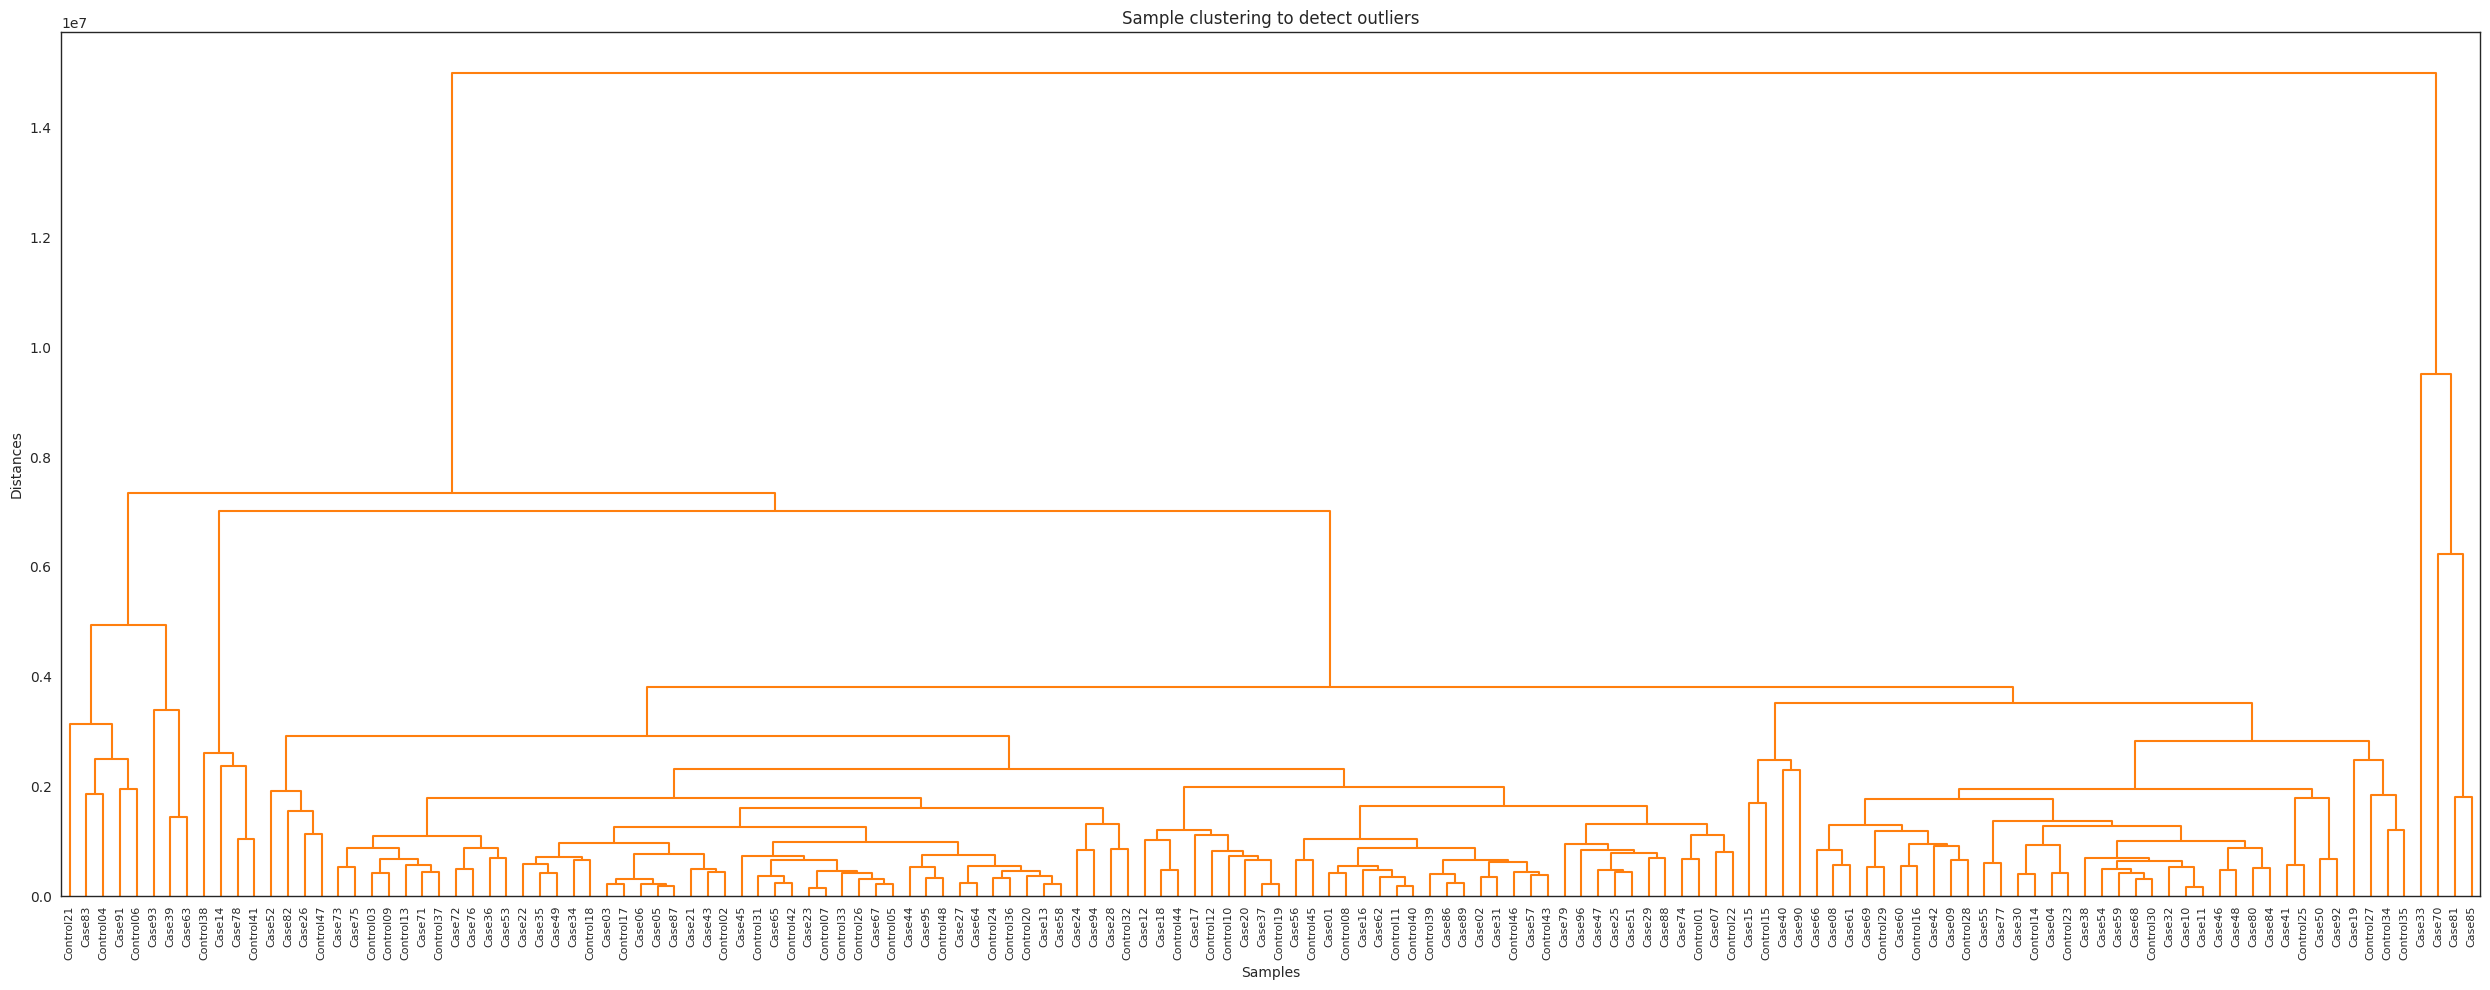

In [ ]:
import pandas as pd
import PyWGCNA

normalized_counts_df = pd.read_csv("GSE234297_normalized_counts.txt", sep="\t", index_col=0)

pyWGCNA_ALS = PyWGCNA.WGCNA(
    name='GSE234297_ALS',
    species='homo sapiens',
    geneExp=normalized_counts_df,
    outputPath='',
    save=True
)

pyWGCNA_ALS.preprocess()

In [ ]:
pyWGCNA_ALS.updateSampleInfo(path='GSE234297_phenotype.txt', sep='\t')

In [ ]:
pyWGCNA_ALS.findModules()

Run WGCNA...
pickSoftThreshold: calculating connectivity for given powers...
will use block size  1600
    Power  SFT.R.sq     slope truncated R.sq      mean(k)    median(k)  \
0       1  0.765037   -1.3714       0.911897  1616.443983  1339.678745   
1       2  0.900747 -1.611617       0.932064   445.214184   252.098362   
2       3  0.893565 -1.561452       0.939003   183.250151    69.883862   
3       4  0.892824 -1.544624       0.953203    94.101169    28.557239   
4       5  0.894849 -1.560215       0.965664    54.971753    13.648313   
5       6  0.911318 -1.580127       0.982134    34.896139     7.074352   
6       7   0.90954 -1.618848         0.9843    23.505189      3.87194   
7       8  0.916459 -1.649185       0.991381    16.576562     2.191038   
8       9  0.915003   -1.6732       0.992515    12.140785     1.268746   
9      10  0.905768 -1.694785       0.992589      9.18585     0.747208   
10     11  0.897209 -1.701386       0.994463     7.153143     0.444547   
11     13

In [ ]:
print([attr for attr in dir(pyWGCNA_ALS) if not attr.startswith('_')])

['CalculateSignedKME', 'CoexpressionModulePlot', 'MEDissThres', 'MEs', 'MeanCut', 'PPI_network', 'RsquaredCut', 'TOM', 'TOMType', 'TOMsimilarity', 'TPMcutoff', 'TomSimilarityFromAdj', 'adjacency', 'analyseWGCNA', 'barplotModuleEigenGene', 'calBlockSize', 'checkAdjMat', 'checkAndScaleWeights', 'checkSets', 'checkSimilarity', 'clustOrder', 'consensusMEDissimilarity', 'consensusMEDissimilarityMajor', 'consensusOrderMEs', 'coreSizeFunc', 'cut', 'cutree', 'cutreeHybrid', 'datExpr', 'datME', 'dynamicMods', 'equalizeQuantilesFun', 'figureType', 'findModules', 'fixDataStructure', 'functional_enrichment_analysis', 'geneExpr', 'geneTree', 'getDatTraits', 'getGeneModule', 'getModuleName', 'getModulesGene', 'get_heights', 'get_merges', 'goodGenesFun', 'goodSamplesFun', 'goodSamplesGenes', 'hclust', 'interpolate', 'intramodularConnectivity', 'labels2colors', 'level', 'mergeCloseModules', 'metadataColors', 'minModuleSize', 'moduleEigengenes', 'moduleNumber', 'moduleTraitCor', 'moduleTraitPvalue', 'm

In [ ]:
import os
print(os.listdir())

['.config', 'GSE234297_normalized_counts.txt', 'GSE234297_DESeq2_results.txt', 'GSE234297_ALS_only.txt', 'GSE234297_DESeq2_full_results.txt', 'GSE234297_phenotype.txt', 'GSE234297_DEG_gene_list.txt', 'GSE234297_PCA_plot.png', 'GSE234297_control_only.txt', 'GSE234297_volcano_plot.png', 'GSE234297_gene_raw_counts_rounded.txt', 'GSE234297_significant_DEGs.txt', 'figures', 'sample_data']


Saving data to be True, checking requirements ...
Pre-processing...
	Detecting genes and samples with too many missing values...
	Done pre-processing..

Run WGCNA...
pickSoftThreshold: calculating connectivity for given powers...
will use block size  5000
    Power  SFT.R.sq     slope truncated R.sq     mean(k)   median(k)  \
0       1  0.324673  0.690884       0.810011  856.718608  893.234089   
1       2  0.083908 -0.302329       0.567716  408.134996  421.849442   
2       3  0.305646 -0.718693       0.650855  228.701746  221.063018   
3       4  0.426341 -0.891451       0.706436   140.66985   124.70328   
4       5  0.584928 -0.927208       0.798403   92.018969   75.169374   
5       6  0.711177 -0.987429       0.906381   62.922982   48.103975   
6       7  0.738439 -1.145923       0.934681   44.506028   31.794867   
7       8  0.755283 -1.275825       0.946722   32.335609   21.414654   
8       9  0.779924 -1.356799       0.965632   24.014935   14.807178   
9      10  0.802019 -1.4

ValueError: assignment destination is read-only

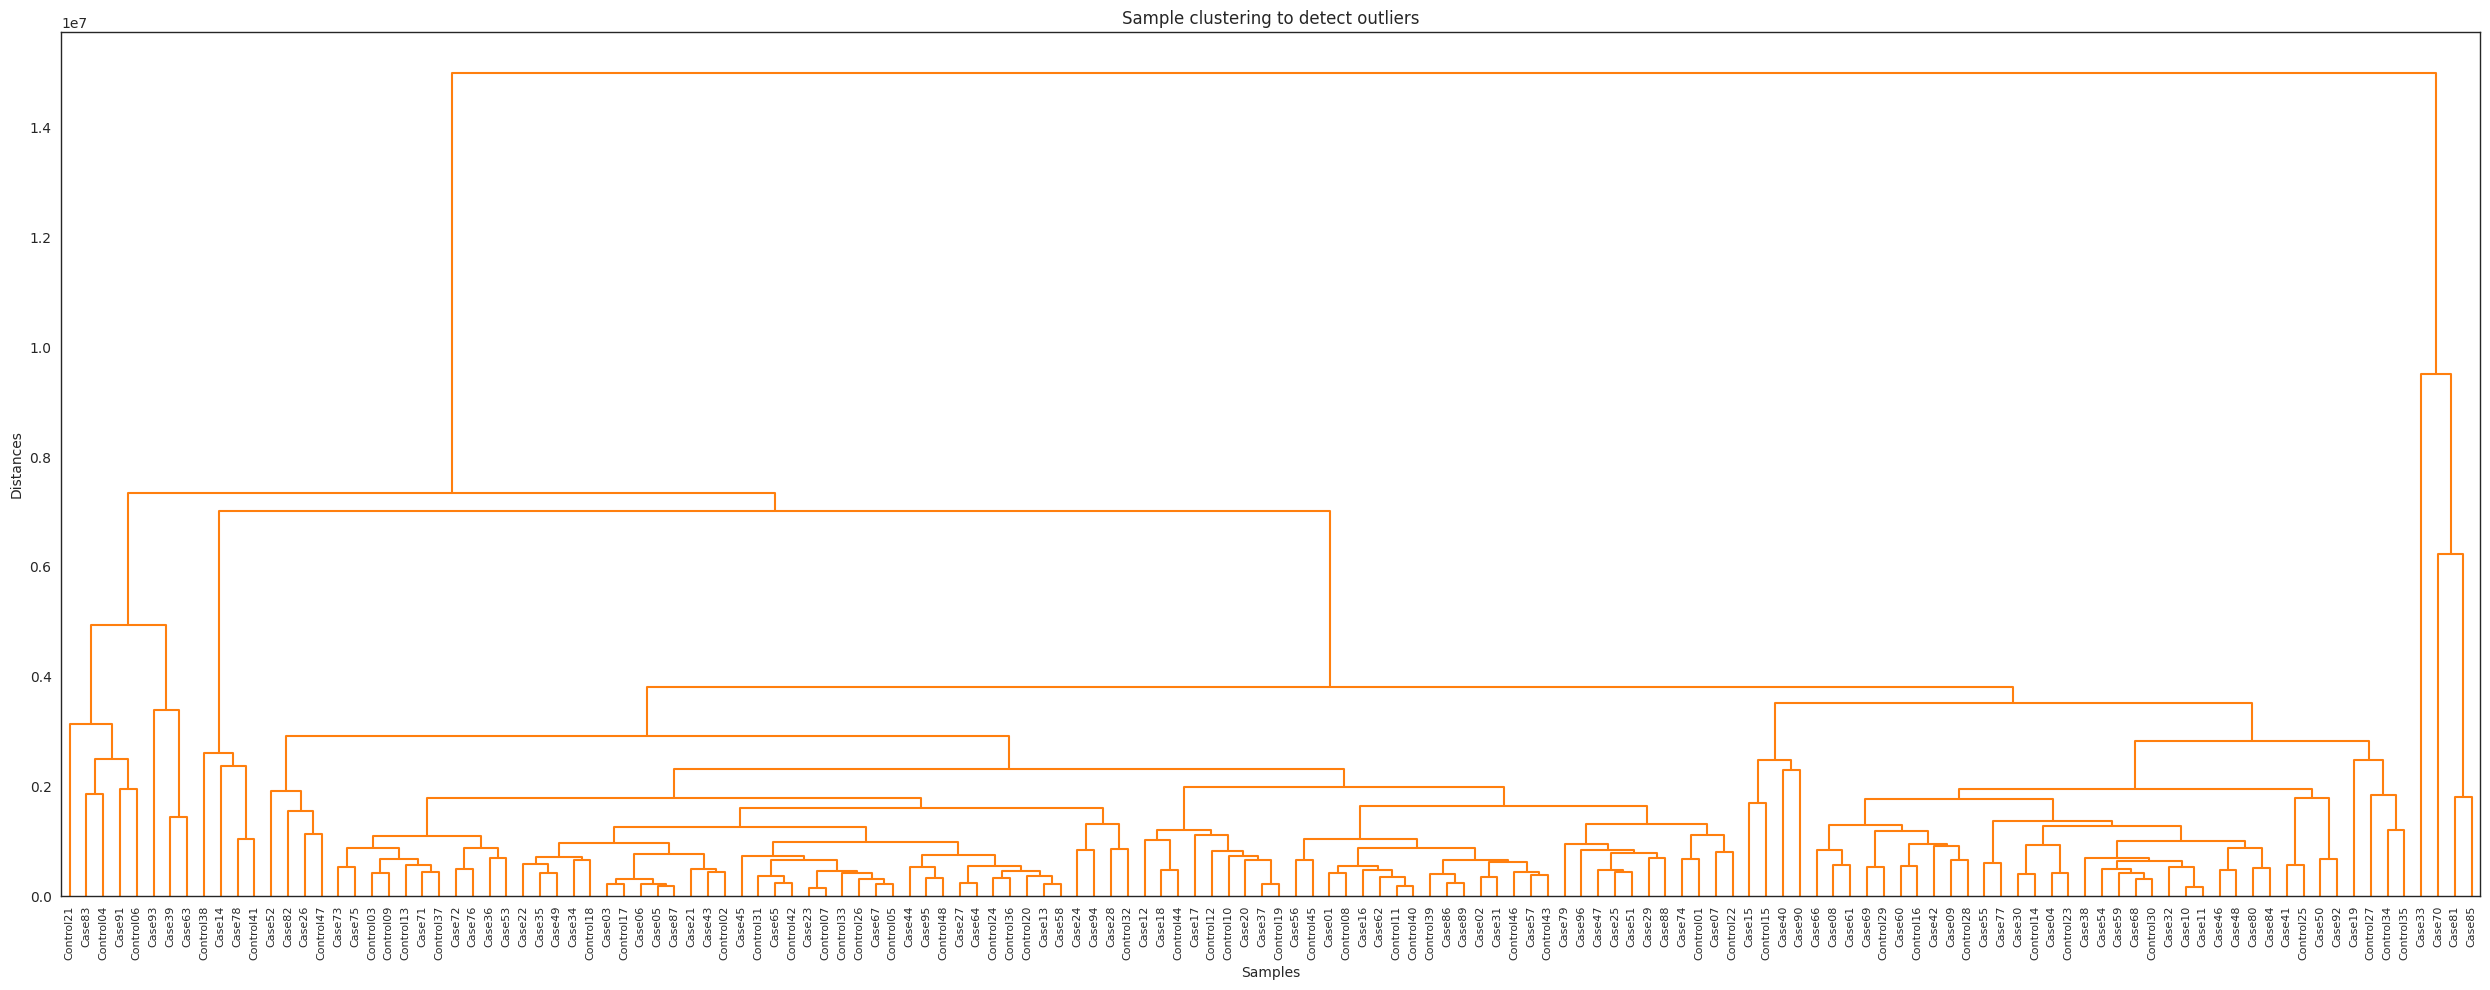

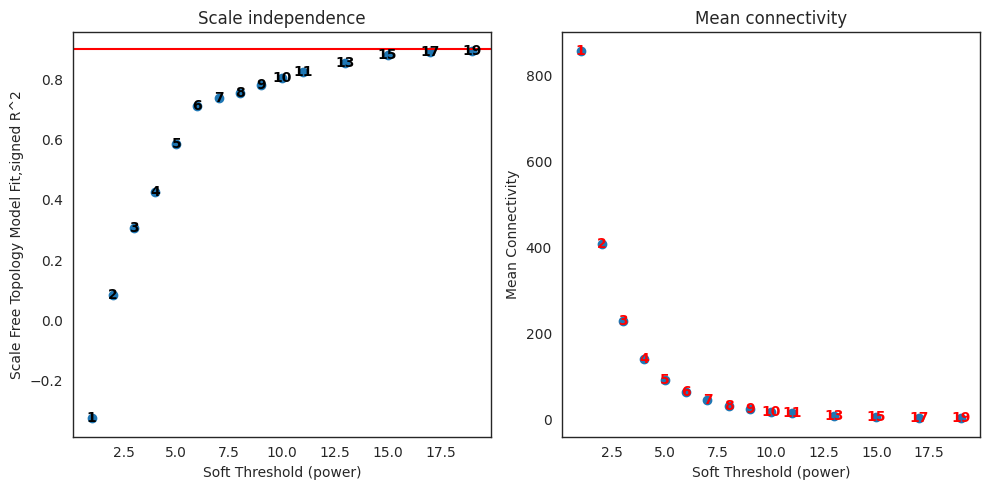

In [ ]:
import pandas as pd
import numpy as np
import PyWGCNA

normalized_counts_df = pd.read_csv("GSE234297_normalized_counts.txt", sep="\t", index_col=0)

gene_variance = normalized_counts_df.var(axis=0)
top_genes = gene_variance.sort_values(ascending=False).head(5000).index
filtered_counts = normalized_counts_df[top_genes].copy()   # .copy() fixes the read-only error from before

pyWGCNA_ALS = PyWGCNA.WGCNA(
    name='GSE234297_ALS',
    species='homo sapiens',
    geneExp=filtered_counts,
    outputPath='',
    save=True
)

pyWGCNA_ALS.preprocess()
pyWGCNA_ALS.findModules()

In [ ]:
import pandas as pd

# Reload DESeq2 results (adjust filename if needed)
results_df = pd.read_csv("GSE234297_DESeq2_full_results.txt", sep="\t", index_col=0)

# Filter to significant DEGs
sig_degs = results_df[results_df["padj"] < 0.05]
deg_ids = set(sig_degs.index.astype(str))
print(f"Significant DEGs: {len(deg_ids)}")

# Load ME4 module genes (upload GSE234297_ME4_genes.txt to this session first)
with open("GSE234297_ME4_genes.txt") as f:
    me4_ids = set(line.strip() for line in f if line.strip())
print(f"ME4 module genes: {len(me4_ids)}")

# Intersection
overlap = deg_ids & me4_ids
print(f"Overlap (DEG ∩ ME4): {len(overlap)}")

# Save as plain gene ID list
with open("GSE234297_DEG_ME4_intersection.txt", "w") as f:
    for gene in sorted(overlap, key=int):
        f.write(gene + "\n")

print("Saved: GSE234297_DEG_ME4_intersection.txt")

Significant DEGs: 290
ME4 module genes: 352
Overlap (DEG ∩ ME4): 100
Saved: GSE234297_DEG_ME4_intersection.txt


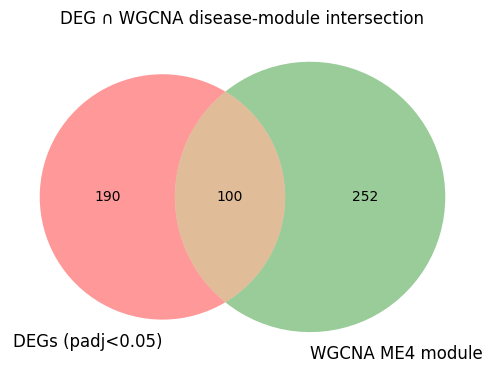

LASSO selected 8 genes: ['3480', '3660', '3772', '8554', '9466', '9541', '53829', '55350']

Top 20 RF genes: ['8569', '3480', '22990', '3660', '3556', '5663', '3837', '105378415', '6732', '9878', '9466', '3772', '53829', '23344', '8676', '79887', '10109', '2932', '10261', '55350']

Final hub genes (LASSO ∩ RF): 6 {'53829', '3480', '3772', '3660', '9466', '55350'}

5-fold CV accuracy: 0.674 (+/- 0.085)


In [ ]:
!pip install pydeseq2 matplotlib-venn -q

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

# Reload everything from saved files (in case session reset)
normalized_counts_df = pd.read_csv("GSE234297_normalized_counts.txt", sep="\t", index_col=0)
results_df = pd.read_csv("GSE234297_DESeq2_full_results.txt", sep="\t", index_col=0)
pheno = pd.read_csv("GSE234297_phenotype.txt", sep="\t").set_index("sample")

sig_degs = results_df[results_df["padj"] < 0.05]
deg_ids = set(sig_degs.index.astype(str))

with open("GSE234297_ME4_genes.txt") as f:
    me4_ids = set(line.strip() for line in f if line.strip())

with open("GSE234297_DEG_ME4_intersection.txt") as f:
    candidate_genes = [line.strip() for line in f if line.strip()]

# Venn diagram
plt.figure(figsize=(6,6))
venn2([deg_ids, me4_ids], set_labels=("DEGs (padj<0.05)", "WGCNA ME4 module"))
plt.title("DEG ∩ WGCNA disease-module intersection")
plt.savefig("GSE234297_venn.png", dpi=300)
plt.show()

# ML feature selection on the 100-gene intersection
X = normalized_counts_df[candidate_genes].copy()
X = np.log2(X + 1)

y = pheno.loc[X.index, "condition"]
y_binary = (y == "ALS").astype(int)

X_scaled = pd.DataFrame(StandardScaler().fit_transform(X), index=X.index, columns=X.columns)

lasso = LogisticRegression(penalty="l1", solver="liblinear", C=0.1, max_iter=5000, random_state=42)
lasso.fit(X_scaled, y_binary)
lasso_coefs = pd.Series(lasso.coef_[0], index=X.columns)
lasso_selected = lasso_coefs[lasso_coefs != 0].index.tolist()
print(f"LASSO selected {len(lasso_selected)} genes:", lasso_selected)

rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_scaled, y_binary)
rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
rf_selected = rf_importance.head(20).index.tolist()
print("\nTop 20 RF genes:", rf_selected)

final_hub_genes = set(lasso_selected) & set(rf_selected)
print(f"\nFinal hub genes (LASSO ∩ RF): {len(final_hub_genes)}", final_hub_genes)

if len(final_hub_genes) > 0:
    X_final = X_scaled[list(final_hub_genes)]
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(rf, X_final, y_binary, cv=cv, scoring="accuracy")
    print(f"\n5-fold CV accuracy: {scores.mean():.3f} (+/- {scores.std():.3f})")

In [ ]:
!pip install mygene -q
import mygene

mg = mygene.MyGeneInfo()
hub_genes = ['53829', '3480', '3772', '3660', '9466', '55350']

gene_info = mg.querymany(hub_genes, scopes='entrezgene', fields='symbol,name', species='human')
for g in gene_info:
    print(g.get('query'), '->', g.get('symbol'), '-', g.get('name'))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.1/52.1 kB 1.7 MB/s eta 0:00:00


INFO:biothings.client:querying 1-6 ...
INFO:biothings.client:Finished.


53829 -> P2RY13 - purinergic receptor P2Y13
3480 -> IGF1R - insulin like growth factor 1 receptor
3772 -> KCNJ15 - potassium inwardly rectifying channel subfamily J member 15
3660 -> IRF2 - interferon regulatory factor 2
9466 -> IL27RA - interleukin 27 receptor subunit alpha
55350 -> VNN3P - vanin 3, pseudogene
